<a href="https://colab.research.google.com/github/cavalcantiju/visaocomp-2.2-engdados/blob/main/semana2_engdados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

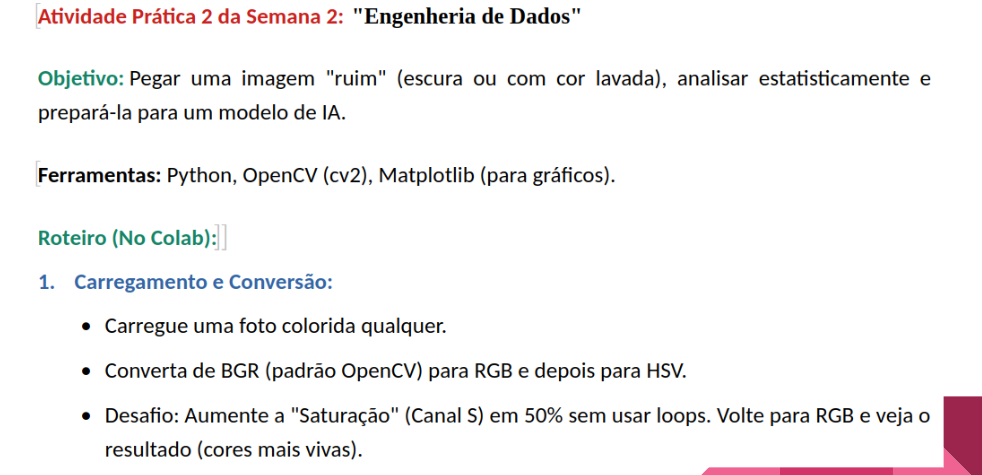

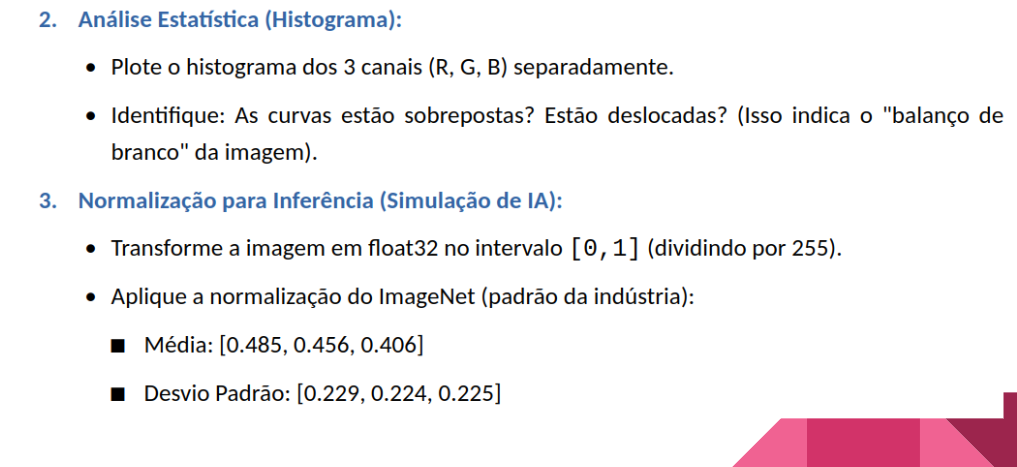

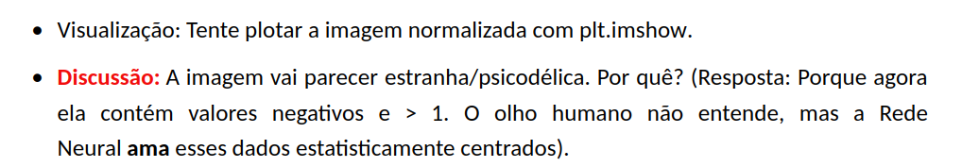

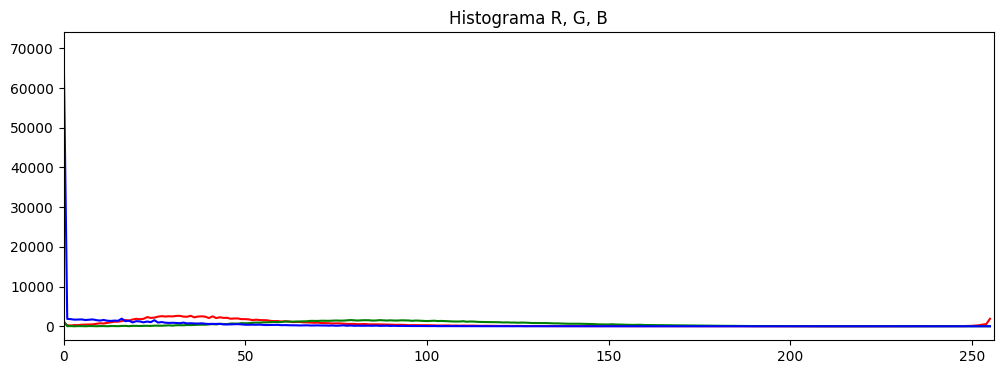

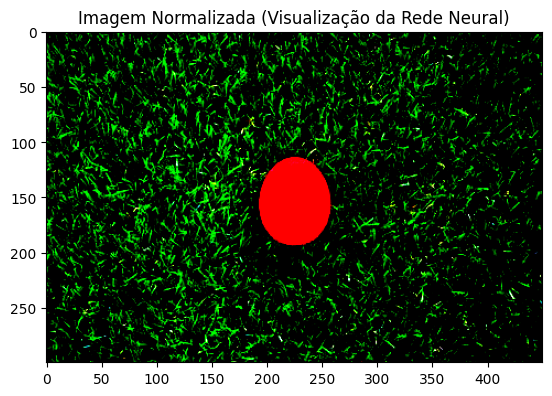

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregamento e Conversão
img_bgr = cv2.imread('egg.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)

# Desafio: Aumentar Saturação em 50% (Canal S é o índice 1)
# Usamos np.clip para garantir que os valores não passem de 255
img_hsv[:, :, 1] = np.clip(img_hsv[:, :, 1] * 1.5, 0, 255)
img_vivida = cv2.cvtColor(img_hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

# 2. Análise Estatística (Histograma)
plt.figure(figsize=(12, 4))
cores = ('r', 'g', 'b')
for i, col in enumerate(cores):
    hist = cv2.calcHist([img_vivida], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)
    plt.xlim([0, 256])
plt.title("Histograma R, G, B")
plt.show()

# 3. Normalização para Inferência (ImageNet)
# Passo A: Transformar em float32 no intervalo [0, 1]
img_norm = img_vivida.astype(np.float32) / 255.0

# Passo B: Aplicar Média e Desvio Padrão do ImageNet
media = np.array([0.485, 0.456, 0.406])
desvio = np.array([0.229, 0.224, 0.225])
img_final = (img_norm - media) / desvio

# Visualização Psicodélica
plt.imshow(img_final)
plt.title("Imagem Normalizada (Visualização da Rede Neural)")
plt.show()

Manipulação no HSV: Para aumentar a vivacidade das cores, não mexemos no RGB. Fomos para o espaço HSV e multiplicamos o canal S (Saturação) por 1.5. Usamos o np.clip para evitar que o valor estourasse o limite de 255.

O Histograma: Ele funciona como um 'raio-x' da imagem. Se as curvas coloridas estiverem muito separadas, a foto tem um desequilíbrio de branco (está muito azulada ou amarelada). Se estiverem sobrepostas, as cores estão equilibradas.

Normalização ImageNet: Esse é o padrão da indústria. As redes neurais (como ResNet ou VGG) foram treinadas com milhões de imagens que possuem essa média e desvio padrão específicos.